In [10]:
import pandas as pd
import re

# 1. Defina o caminho do arquivo (Ajuste se necessário)
file_path = "DATATHON.xlsx"

# 2. Função robusta para limpar os nomes das colunas de cada aba
def limpar_colunas(df):
    # Passa tudo para maiúsculo e tira espaços sobrando
    cols = df.columns.str.strip().str.upper()

    # Remove os anos do final, mas mantendo histórico antigo se quiser (opcional)
    # Aqui removemos especificamente 22, 23, 24 e 2022, 2023, 2024 do sufixo
    cols = cols.str.replace(r'\s*(2022|22|2023|23|2024|24)$', '', regex=True)
    df.columns = cols

    # Como removemos os sufixos, algumas colunas de histórico (ex: PEDRA 21, PEDRA 22)
    # podem ter ficado com o mesmo nome ('PEDRA').
    # Essa linha mantém apenas a primeira coluna nesses casos de empate.
    df = df.loc[:, ~df.columns.duplicated()].copy()

    return df

# 3. Carregar e limpar cada base
print("Carregando e limpando as abas...")
df_2022 = limpar_colunas(pd.read_excel(file_path, sheet_name='PEDE2022'))
df_2023 = limpar_colunas(pd.read_excel(file_path, sheet_name='PEDE2023'))
df_2024 = limpar_colunas(pd.read_excel(file_path, sheet_name='PEDE2024'))

# 4. Adicionar a coluna de Ano da Pesquisa para rastreabilidade
df_2022['ANO_PESQUISA'] = 2022
df_2023['ANO_PESQUISA'] = 2023
df_2024['ANO_PESQUISA'] = 2024

# 5. Concatenar todas as bases em uma só
df_completo = pd.concat([df_2022, df_2023, df_2024], ignore_index=True)

# 6. Função para mesclar colunas que significam a mesma coisa mas têm nomes diferentes
def unificar_colunas(df, col_principal, col_secundaria):
    if col_principal in df.columns and col_secundaria in df.columns:
        # Preenche os vazios da principal com os dados da secundária
        df[col_principal] = df[col_principal].combine_first(df[col_secundaria])
        # Exclui a secundária
        df.drop(columns=[col_secundaria], inplace=True)
    return df

# 7. Unificando as variações de grafia encontradas
print("Unificando colunas com variações de grafia...")
df_completo = unificar_colunas(df_completo, 'GENERO', 'GÊNERO')
df_completo = unificar_colunas(df_completo, 'INGLES', 'INGLÊS')
df_completo = unificar_colunas(df_completo, 'INGLES', 'ING') # As vezes abreviado
df_completo = unificar_colunas(df_completo, 'PORTUGUES', 'PORTUGUÊS')
df_completo = unificar_colunas(df_completo, 'PORTUGUES', 'PORTUG')
df_completo = unificar_colunas(df_completo, 'PORTUGUES', 'POR')
df_completo = unificar_colunas(df_completo, 'MATEMATICA', 'MATEM')
df_completo = unificar_colunas(df_completo, 'MATEMATICA', 'MAT')
df_completo = unificar_colunas(df_completo, 'INSTITUICAO DE ENSINO', 'INSTITUIÇÃO DE ENSINO')
df_completo = unificar_colunas(df_completo, 'INSTITUICAO DE ENSINO', 'ESCOLA')
df_completo = unificar_colunas(df_completo, 'DEFAS', 'DEFASAGEM')

# 8. Visão final da base
print(f"\n--- SUCESSO! ---")
print(f"Tamanho da base final: {df_completo.shape[0]} linhas e {df_completo.shape[1]} colunas.")
print("\nLista de Colunas Disponíveis para Análise:")
print(sorted(df_completo.columns.tolist()))

# Exportar para um CSV limpo para facilitar os próximos passos (Opcional, mas recomendado)
df_completo.to_csv("base_datathon_limpa.csv", index=False)

Carregando e limpando as abas...
Unificando colunas com variações de grafia...

--- SUCESSO! ---
Tamanho da base final: 3030 linhas e 55 colunas.

Lista de Colunas Disponíveis para Análise:
['ANO INGRESSO', 'ANO NASC', 'ANO_PESQUISA', 'ATINGIU PV', 'ATIVO/ INATIVO', 'ATIVO/ INATIVO.1', 'AVALIADOR1', 'AVALIADOR2', 'AVALIADOR3', 'AVALIADOR4', 'AVALIADOR5', 'AVALIADOR6', 'CF', 'CG', 'CT', 'DATA DE NASC', 'DEFAS', 'DESTAQUE IDA', 'DESTAQUE IEG', 'DESTAQUE IPV', 'DESTAQUE IPV.1', 'ESCOLA', 'FASE', 'FASE IDEAL', 'GÊNERO', 'IAA', 'IAN', 'IDA', 'IDADE', 'IEG', 'INDE', 'INDICADO', 'ING', 'INGLÊS', 'INSTITUIÇÃO DE ENSINO', 'IPP', 'IPS', 'IPV', 'MAT', 'MATEM', 'NOME', 'NOME ANONIMIZADO', 'Nº AV', 'PEDRA', 'PEDRA 20', 'PEDRA 21', 'POR', 'PORTUG', 'RA', 'REC AV1', 'REC AV2', 'REC AV3', 'REC AV4', 'REC PSICOLOGIA', 'TURMA']


#Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao longo do ano? (Ex.: quantos alunos estão moderadamente ou severamente defasados?. O número de alunos com nível "Adequado (IAN 10)" dá um salto gigantesco de 2022 para 2024 (passando de cerca de 250 para mais de 600 alunos). Em contrapartida, os alunos em defasagem severa (IAN 2.5) e moderada (IAN 5) vêm diminuindo. Isso já prova, na primeira pergunta, a efetividade do programa!

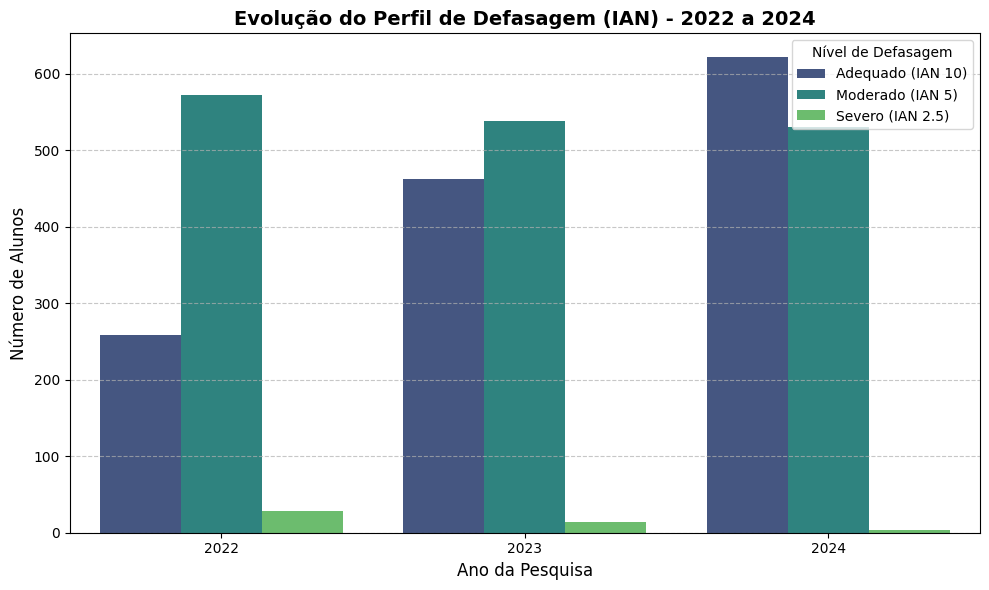


Tabela Resumo: Quantidade de alunos por perfil ao longo dos anos:
Perfil_Defasagem  Adequado (IAN 10)  Moderado (IAN 5)  Severo (IAN 2.5)
ANO_PESQUISA                                                           
2022                            259               573                28
2023                            462               538                14
2024                            622               531                 3


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregar a base limpa (caso tenha fechado o notebook)
# df_completo = pd.read_csv("base_datathon_limpa.csv")

# 2. Criar uma função para categorizar o nível de defasagem baseado no IAN
def categorizar_ian(nota):
    if nota == 10.0:
        return 'Adequado (IAN 10)'
    elif nota == 5.0:
        return 'Moderado (IAN 5)'
    elif nota == 2.5:
        return 'Severo (IAN 2.5)'
    else:
        return 'Outros'

# 3. Aplicar a função para criar uma nova coluna
df_completo['Perfil_Defasagem'] = df_completo['IAN'].apply(categorizar_ian)

# 4. Preparar os dados para plotagem: Contar quantos alunos em cada perfil por ano
resumo_ian = df_completo.groupby(['ANO_PESQUISA', 'Perfil_Defasagem']).size().reset_index(name='Quantidade')

# 5. Criar o gráfico com a evolução
plt.figure(figsize=(10, 6))
sns.barplot(data=resumo_ian, x='ANO_PESQUISA', y='Quantidade', hue='Perfil_Defasagem', palette='viridis')

# Estilização para o PPT Gerencial
plt.title('Evolução do Perfil de Defasagem (IAN) - 2022 a 2024', fontsize=14, fontweight='bold')
plt.xlabel('Ano da Pesquisa', fontsize=12)
plt.ylabel('Número de Alunos', fontsize=12)
plt.legend(title='Nível de Defasagem')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar e salvar o gráfico
plt.tight_layout()
plt.savefig('evolucao_ian.png', dpi=300) # Salva em alta qualidade para a apresentação
plt.show()

# 6. Exibir os números exatos em formato de tabela cruzada
print("\nTabela Resumo: Quantidade de alunos por perfil ao longo dos anos:")
tabela_cruzada = pd.crosstab(df_completo['ANO_PESQUISA'], df_completo['Perfil_Defasagem'])
print(tabela_cruzada)

#analisar o Desempenho acadêmico (IDA) e descobrir se ele está melhorando, estagnado ou caindo ao longo das fases e anos.

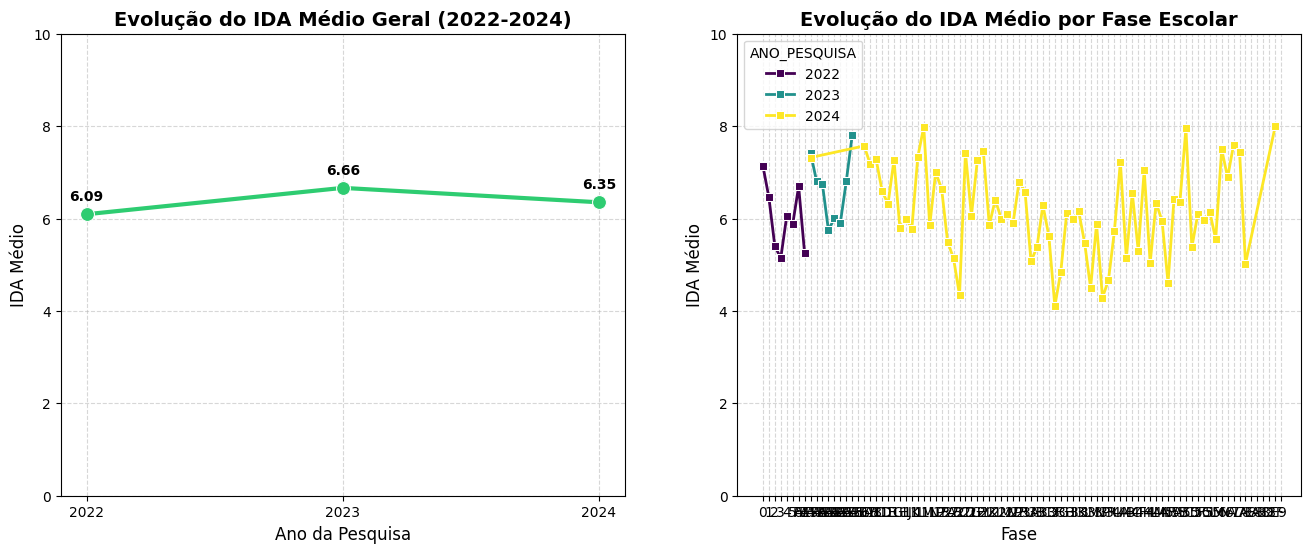

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Calcular o IDA Médio Geral por Ano
ida_por_ano = df_completo.groupby('ANO_PESQUISA')['IDA'].mean().reset_index()

# 2. Calcular o IDA Médio por Fase e Ano
# Como podem haver variações de texto/número na fase, garantimos que seja tratado como string para o gráfico
df_completo['FASE_STR'] = df_completo['FASE'].astype(str)
ida_ano_fase = df_completo.groupby(['ANO_PESQUISA', 'FASE_STR'])['IDA'].mean().reset_index()

# 3. Configurar a área de plotagem (1 linha, 2 colunas para colocar lado a lado)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- GRÁFICO 1: Evolução Geral ---
sns.lineplot(data=ida_por_ano, x='ANO_PESQUISA', y='IDA', marker='o', ax=axes[0], color='#2ecc71', linewidth=3, markersize=10)
axes[0].set_title('Evolução do IDA Médio Geral (2022-2024)', fontsize=14, fontweight='bold')
axes[0].set_xticks([2022, 2023, 2024])
axes[0].set_ylabel('IDA Médio', fontsize=12)
axes[0].set_xlabel('Ano da Pesquisa', fontsize=12)
axes[0].set_ylim(0, 10) # Manter a escala de 0 a 10 para notas
axes[0].grid(True, linestyle='--', alpha=0.5)

# Adicionando os rótulos de dados no Gráfico 1
for x, y in zip(ida_por_ano['ANO_PESQUISA'], ida_por_ano['IDA']):
    axes[0].text(x, y + 0.3, f'{y:.2f}', ha='center', fontweight='bold')

# --- GRÁFICO 2: Evolução por Fase ---
# Ordenando as fases para o gráfico fazer sentido (ex: Fase 1, 2, 3...)
ordem_fases = sorted(df_completo['FASE_STR'].dropna().unique())

sns.lineplot(data=ida_ano_fase, x='FASE_STR', y='IDA', hue='ANO_PESQUISA', marker='s', ax=axes[1], palette='viridis', linewidth=2)
axes[1].set_title('Evolução do IDA Médio por Fase Escolar', fontsize=14, fontweight='bold')
axes[1].set_ylabel('IDA Médio', fontsize=12)
axes[1].set_xlabel('Fase', fontsize=12)
axes[1].set_ylim(0, 10)
axes[1].grid(True, linestyle='--', alpha=0.5)

##O grau de engajamento dos alunos (IEG) tem relação direta com seus indicadores de desempenho (IDA) e do ponto de virada (IPV)?

Para responder a essa pergunta, precisamos realizar uma Análise de Correlação. Vamos calcular a correlação matemática (Pearson) entre essas três variáveis para ver a força dessa relação e gerar gráficos de dispersão (scatter plots). Isso nos ajudará a provar visualmente se um alto engajamento (IEG) "puxa" o desempenho (IDA) e o desenvolvimento emocional/acadêmico (IPV) do aluno para cima.

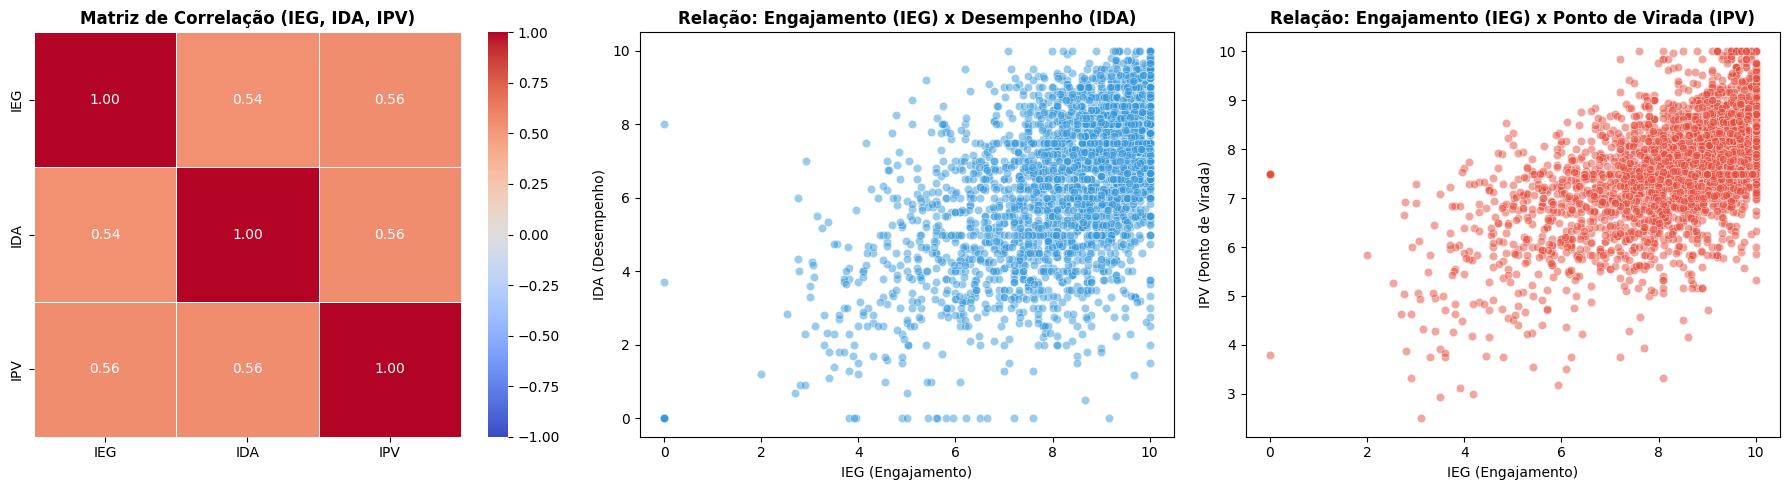

Valores da Correlação de Pearson:
       IEG    IDA    IPV
IEG  1.000  0.543  0.558
IDA  0.543  1.000  0.557
IPV  0.558  0.557  1.000


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Isolar as colunas de interesse e remover nulos para o cálculo
colunas_foco = ['IEG', 'IDA', 'IPV']
df_correlacao = df_completo[colunas_foco].dropna()

# 2. Calcular a matriz de correlação de Pearson
matriz_corr = df_correlacao.corr()

# 3. Configurar a área de plotagem (1 linha, 3 colunas)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- GRÁFICO 1: Heatmap da Correlação ---
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0], fmt=".2f", linewidths=.5)
axes[0].set_title('Matriz de Correlação (IEG, IDA, IPV)', fontsize=12, fontweight='bold')

# --- GRÁFICO 2: Dispersão IEG vs IDA ---
sns.scatterplot(data=df_completo, x='IEG', y='IDA', alpha=0.5, ax=axes[1], color='#3498db')
axes[1].set_title('Relação: Engajamento (IEG) x Desempenho (IDA)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('IEG (Engajamento)')
axes[1].set_ylabel('IDA (Desempenho)')

# --- GRÁFICO 3: Dispersão IEG vs IPV ---
sns.scatterplot(data=df_completo, x='IEG', y='IPV', alpha=0.5, ax=axes[2], color='#e74c3c')
axes[2].set_title('Relação: Engajamento (IEG) x Ponto de Virada (IPV)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('IEG (Engajamento)')
axes[2].set_ylabel('IPV (Ponto de Virada)')

# 4. Ajustar layout e salvar a imagem para o PPT
plt.tight_layout()
plt.savefig('correlacao_ieg.png', dpi=300)
plt.show()

# 5. Exibir os valores numéricos no console
print("Valores da Correlação de Pearson:")
print(matriz_corr.round(3))

##As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)?  Breve Descrição:Vamos cruzar a Autoavaliação (IAA) com o Desempenho (IDA) e o Engajamento (IEG) usando gráficos de dispersão e calculando a correlação. Isso mostrará se os alunos têm uma visão realista de si mesmos (ex: notas altas no IAA refletem notas altas no IDA/IEG).

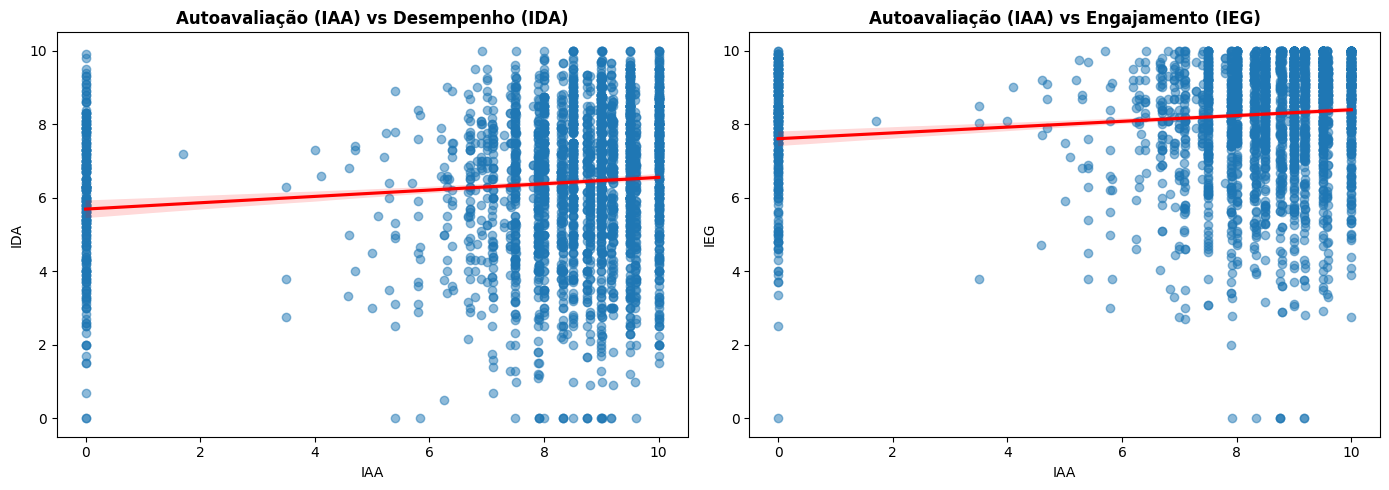

Correlação IAA x IDA: 0.115
Correlação IAA x IEG: 0.131


In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Isolar dados e remover nulos
df_iaa = df_completo[['IAA', 'IDA', 'IEG']].dropna()

# 2. Configurar gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: IAA x IDA
sns.regplot(data=df_iaa, x='IAA', y='IDA', scatter_kws={'alpha':0.5}, line_kws={'color':'red'}, ax=axes[0])
axes[0].set_title('Autoavaliação (IAA) vs Desempenho (IDA)', fontweight='bold')

# Gráfico 2: IAA x IEG
sns.regplot(data=df_iaa, x='IAA', y='IEG', scatter_kws={'alpha':0.5}, line_kws={'color':'red'}, ax=axes[1])
axes[1].set_title('Autoavaliação (IAA) vs Engajamento (IEG)', fontweight='bold')

plt.tight_layout()
plt.savefig('coerencia_iaa.png', dpi=300)
plt.show()

print("Correlação IAA x IDA:", df_iaa['IAA'].corr(df_iaa['IDA']).round(3))
print("Correlação IAA x IEG:", df_iaa['IAA'].corr(df_iaa['IEG']).round(3))

##Há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico ou de engajamento?  Breve Descrição:Vamos categorizar o desempenho (IDA) e o engajamento (IEG) em "Baixo", "Médio" e "Alto" e analisar a distribuição do indicador psicossocial (IPS) dentro dessas categorias através de Boxplots. Se o IPS for consistentemente menor no grupo de "Baixo" desempenho, provamos a relação.

/tmp/ipykernel_5593/1106599749.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_completo, x='Categoria_IDA', y='IPS', palette='Blues', ax=axes[0])
/tmp/ipykernel_5593/1106599749.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_completo, x='Categoria_IEG', y='IPS', palette='Greens', ax=axes[1])


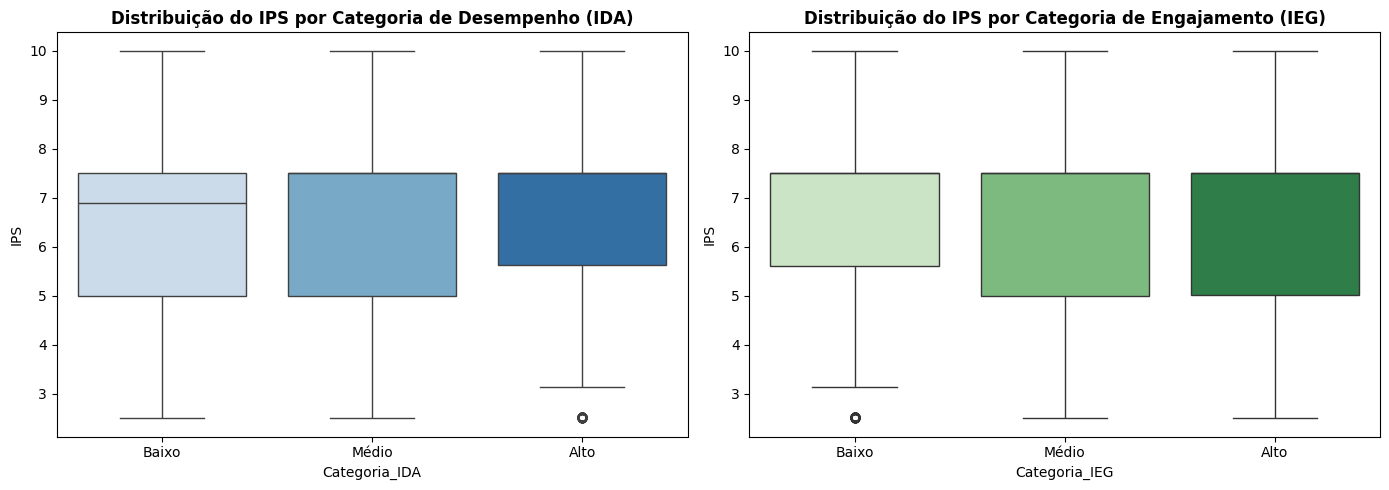

In [22]:
# 1. Categorizar IDA e IEG para análise
df_completo['Categoria_IDA'] = pd.qcut(df_completo['IDA'], q=3, labels=['Baixo', 'Médio', 'Alto'])
df_completo['Categoria_IEG'] = pd.qcut(df_completo['IEG'], q=3, labels=['Baixo', 'Médio', 'Alto'], duplicates='drop')

# 2. Plotar Boxplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_completo, x='Categoria_IDA', y='IPS', palette='Blues', ax=axes[0])
axes[0].set_title('Distribuição do IPS por Categoria de Desempenho (IDA)', fontweight='bold')

sns.boxplot(data=df_completo, x='Categoria_IEG', y='IPS', palette='Greens', ax=axes[1])
axes[1].set_title('Distribuição do IPS por Categoria de Engajamento (IEG)', fontweight='bold')

plt.tight_layout()
plt.savefig('padroes_ips.png', dpi=300)
plt.show()

##As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada pelo IAN?  Breve Descrição:Vamos comparar o IPP diretamente com o perfil de defasagem (IAN) que criamos na Pergunta 1. A ideia é ver se alunos severamente defasados também apresentam avaliações psicopedagógicas mais baixas (confirmando o IAN) ou se os indicadores divergem.Comandos:

Quantidade real de alunos com nota IPP por categoria:
Perfil_Defasagem
Moderado (IAN 5)     1067
Adequado (IAN 10)     908
Severo (IAN 2.5)       17
Name: count, dtype: int64
----------------------------------------


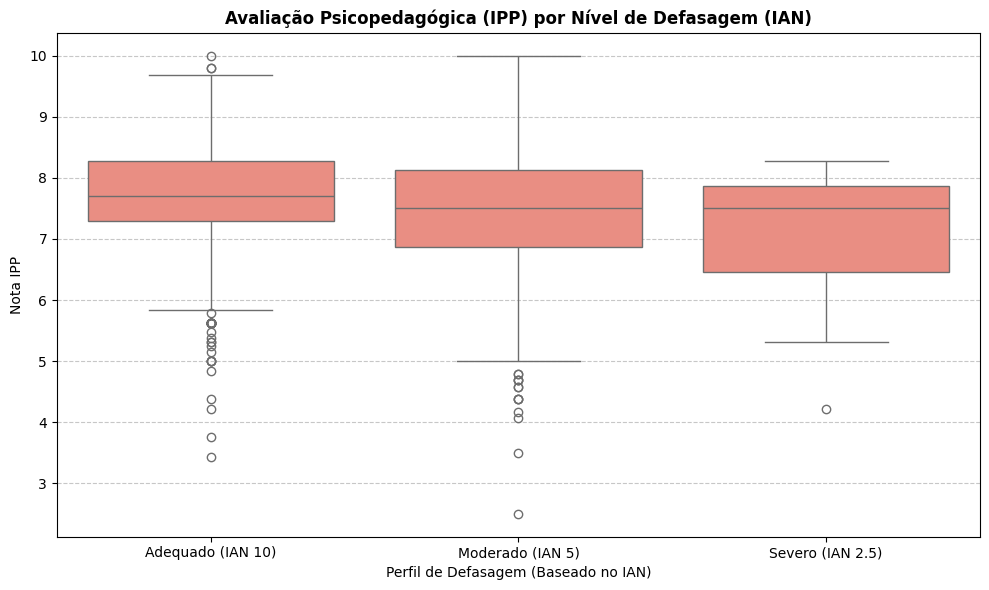

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Garantir que o Perfil de Defasagem existe
if 'Perfil_Defasagem' not in df_completo.columns:
    df_completo['Perfil_Defasagem'] = df_completo['IAN'].apply(lambda x: 'Adequado' if x == 10.0 else ('Moderado' if x == 5.0 else 'Severo'))

# 2. Limpeza removendo os nulos
df_ipp = df_completo.dropna(subset=['IPP', 'Perfil_Defasagem']).copy()

# 3. Diagnóstico: Vamos ver exatamente quantos alunos têm nota IPP!
print("Quantidade real de alunos com nota IPP por categoria:")
print(df_ipp['Perfil_Defasagem'].value_counts())
print("-" * 40)

# 4. Criar Boxplot SEM o parâmetro 'order' forçado
plt.figure(figsize=(10, 6))

# Removemos o 'order' e 'palette' específica para o Seaborn se adaptar aos dados reais
sns.boxplot(data=df_ipp, x='Perfil_Defasagem', y='IPP', color='salmon')

plt.title('Avaliação Psicopedagógica (IPP) por Nível de Defasagem (IAN)', fontweight='bold')
plt.xlabel('Perfil de Defasagem (Baseado no IAN)')
plt.ylabel('Nota IPP')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('ipp_vs_ian.png', dpi=300)
plt.show()

##Quais comportamentos acadêmicos, emocionais ou de engajamento mais influenciam o IPV ao longo do tempo?  Breve Descrição:Faremos uma análise de correlação focada no IPV contra os principais indicadores acadêmicos (IDA, IAN) e emocionais/engajamento (IPS, IEG, IAA, IPP). Plotaremos um gráfico de barras com as correlações ordenadas para descobrir quem tem o maior "peso" na virada do aluno.

/tmp/ipykernel_5593/474631174.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_ipv.index, y=corr_ipv['IPV'], palette='magma')


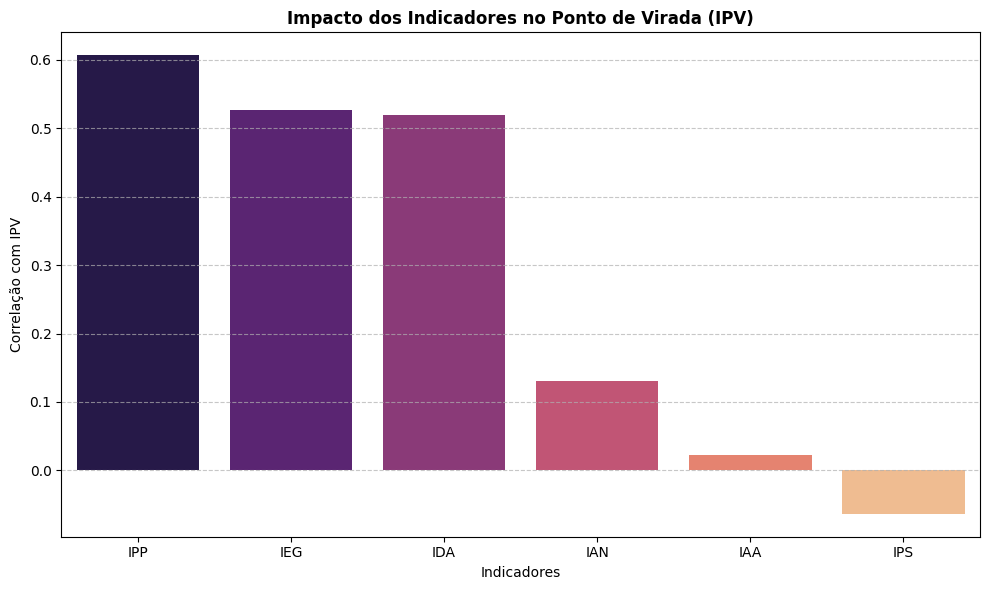

In [26]:
# 1. Isolar indicadores numéricos principais
indicadores = ['IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IAN', 'IPV']
df_ind = df_completo[indicadores].dropna()

# 2. Calcular correlação com o IPV e ordenar
corr_ipv = df_ind.corr()[['IPV']].drop('IPV').sort_values(by='IPV', ascending=False)

# 3. Plotar gráfico de barras da influência
plt.figure(figsize=(10, 6))
sns.barplot(x=corr_ipv.index, y=corr_ipv['IPV'], palette='magma')
plt.title('Impacto dos Indicadores no Ponto de Virada (IPV)', fontweight='bold')
plt.ylabel('Correlação com IPV')
plt.xlabel('Indicadores')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('influencia_ipv.png', dpi=300)
plt.show()

##Quais combinações de indicadores (IDA+IEG+IPS+IPP) elevam mais a nota global do aluno (INDE)?  Breve Descrição:Vamos treinar um modelo de Regressão Linear simples não para prever, mas para extrair os "coeficientes". Esses coeficientes nos dizem matematicamente qual indicador tem o maior peso na composição da nota global (INDE).

Pesos na composição do INDE:
  Indicador  Peso (Coeficiente)
1       IEG            0.254913
0       IDA            0.237186
3       IPP            0.226654
2       IPS            0.117792


/tmp/ipykernel_5593/1879886268.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importancia, x='Indicador', y='Peso (Coeficiente)', palette='crest')


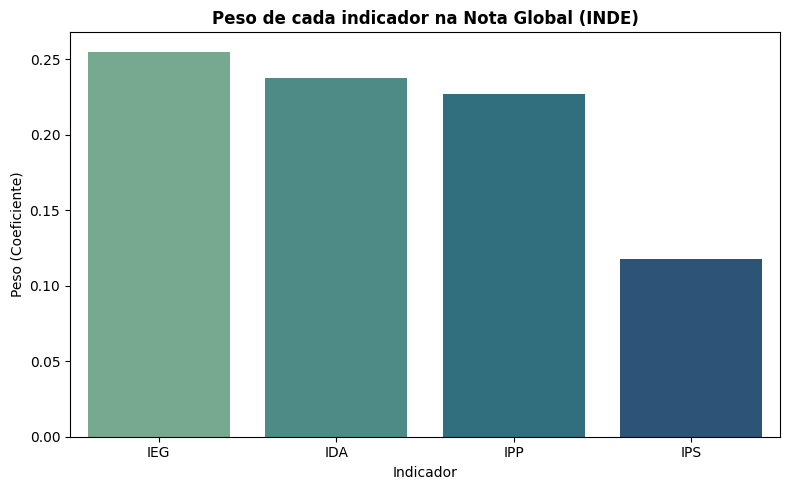

In [27]:
from sklearn.linear_model import LinearRegression
import numpy as np

# 1. Preparar os dados removendo nulos
features = ['IDA', 'IEG', 'IPS', 'IPP']
df_reg = df_completo[features + ['INDE']].dropna()

X = df_reg[features]
y = df_reg['INDE']

# 2. Treinar o modelo
modelo_reg = LinearRegression()
modelo_reg.fit(X, y)

# 3. Extrair a importância (coeficientes)
importancia = pd.DataFrame({'Indicador': features, 'Peso (Coeficiente)': modelo_reg.coef_})
importancia = importancia.sort_values(by='Peso (Coeficiente)', ascending=False)

# 4. Exibir resultados
print("Pesos na composição do INDE:")
print(importancia)

# 5. Visualizar
plt.figure(figsize=(8, 5))
sns.barplot(data=importancia, x='Indicador', y='Peso (Coeficiente)', palette='crest')
plt.title('Peso de cada indicador na Nota Global (INDE)', fontweight='bold')
plt.tight_layout()
plt.savefig('multidimensionalidade_inde.png', dpi=300)
plt.show()

##Construa um modelo preditivo que mostre uma probabilidade do aluno entrar em risco de defasagem.  Breve Descrição:Esta é a preparação do motor do seu aplicativo Streamlit. Vamos criar uma variável alvo binária Risco (1 se o aluno estiver defasado, 0 se estiver adequado), separar os dados em Treino e Teste, e usar um Random Forest Classifier para prever a probabilidade de risco com base nas notas e indicadores. No final, salvamos o modelo em .pkl usando a biblioteca joblib.

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import joblib

# 1. Feature Engineering: Criar a variável alvo "Risco"
# Risco = 1 se o IAN for 5.0 ou 2.5 (Defasado). Risco = 0 se for 10.0 (Adequado)
df_ml = df_completo.copy()
df_ml['Risco'] = np.where(df_ml['IAN'] < 10.0, 1, 0)

# 2. Selecionar features (Variáveis que vão prever o risco)
# Retiramos IAN e DEFAS para o modelo não "trapacear", pois elas definem o risco
features_ml = ['IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV']
df_ml = df_ml[features_ml + ['Risco']].dropna()

X = df_ml[features_ml]
y = df_ml['Risco']

# 3. Separar em Treino e Teste (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Treinar o Modelo Preditivo (Random Forest)
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
modelo_rf.fit(X_train, y_train)

# 5. Avaliar os Resultados
y_pred = modelo_rf.predict(X_test)
y_proba = modelo_rf.predict_proba(X_test)[:, 1] # Probabilidade de ser Risco (1)

print("Relatório de Classificação:")
print(classification_report(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_proba).round(3))

# 6. Salvar o modelo para o deploy no Streamlit
joblib.dump(modelo_rf, 'modelo_risco_passos_magicos.pkl')
print("\nModelo salvo com sucesso como 'modelo_risco_passos_magicos.pkl'!")

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.62      0.38      0.47       192
           1       0.57      0.79      0.66       205

    accuracy                           0.59       397
   macro avg       0.60      0.58      0.57       397
weighted avg       0.60      0.59      0.57       397

AUC-ROC: 0.598

Modelo salvo com sucesso como 'modelo_risco_passos_magicos.pkl'!


Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e Topázio), confirmando o impacto real do programa?  Breve Descrição:Vamos rastrear a nota global (INDE) média através das classificações das "Pedras" adotadas pela associação ao longo dos anos da pesquisa (2022, 2023, 2024). Isso validará se a passagem pelo ciclo formativo institucional de fato consolida o desenvolvimento do aluno.

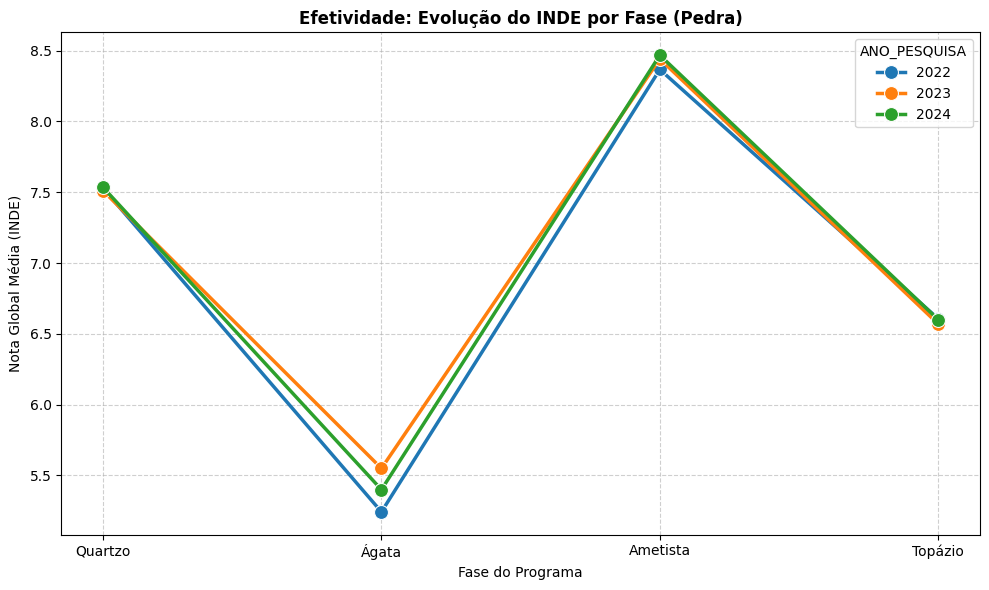

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Isolar dados com FASE (PEDRA) e INDE
df_pedras = df_completo.dropna(subset=['PEDRA', 'INDE']).copy()

# 2. BLINDAGEM DE DADOS: Forçar a coluna INDE a ser número (transforma textos como 'INCLUIR' em nulo)
df_pedras['INDE'] = pd.to_numeric(df_pedras['INDE'], errors='coerce')
df_pedras = df_pedras.dropna(subset=['INDE']) # Remove os nulos que acabamos de criar

# 3. PADRONIZAÇÃO: Arrumar acentos e remover sujeiras
df_pedras['PEDRA'] = df_pedras['PEDRA'].str.title()
df_pedras['PEDRA'] = df_pedras['PEDRA'].str.replace('Agata', 'Ágata') # Corrige o acento
df_pedras = df_pedras[df_pedras['PEDRA'].isin(['Quartzo', 'Ágata', 'Ametista', 'Topázio'])] # Filtra só as pedras reais

# 4. Agrupar a nota média
inde_por_pedra = df_pedras.groupby(['ANO_PESQUISA', 'PEDRA'])['INDE'].mean().reset_index()

# 5. Criar o Gráfico de Linhas (Evolução)
plt.figure(figsize=(10, 6))

# Ordem correta das fases
ordem_pedras = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']

sns.lineplot(data=inde_por_pedra, x='PEDRA', y='INDE', hue='ANO_PESQUISA',
             marker='o', palette='tab10', linewidth=2.5, markersize=10)

plt.title('Efetividade: Evolução do INDE por Fase (Pedra)', fontweight='bold')
plt.xlabel('Fase do Programa')
plt.ylabel('Nota Global Média (INDE)')

# Forçar o eixo X a mostrar as pedras na ordem correta
plt.xticks(ticks=range(len(ordem_pedras)), labels=ordem_pedras)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('efetividade_pedras.png', dpi=300)
plt.show()

##Treinando o Modelo Preditivo (Machine Learning)

In [47]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import joblib

# 1. Definir a Variável Alvo (Risco)
# Vamos considerar que alunos com IAN abaixo de 10.0 possuem algum grau de defasagem (Risco = 1)
df_ml = df_completo.copy()
df_ml['RISCO'] = np.where(df_ml['IAN'] < 10.0, 1, 0)

# 2. Selecionar as Features (Variáveis preditoras)
# Retiramos IAN e DEFAS para o modelo não "trapacear", pois elas definem o risco
features = ['IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV']

# 3. Limpeza crucial: Remover alunos que não tenham todos os indicadores preenchidos
df_ml = df_ml.dropna(subset=features + ['RISCO'])

# Separar X (Características) e y (Alvo)
X = df_ml[features]
y = df_ml['RISCO']

# 4. Separar em dados de Treino (80%) e Teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Treinamento do Modelo (Random Forest)
print("⏳ Treinando o modelo preditivo...")
modelo_rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
modelo_rf.fit(X_train, y_train)

# 6. Avaliação dos Resultados
y_pred = modelo_rf.predict(X_test)
print("\n✅ Relatório de Desempenho do Modelo no Teste:")
print(classification_report(y_test, y_pred))

# 7. Exportar o modelo para o Streamlit
nome_arquivo = 'modelo_risco.pkl'
joblib.dump(modelo_rf, nome_arquivo)
print(f"\n🚀 Sucesso! Modelo encapsulado e salvo como '{nome_arquivo}'.")

⏳ Treinando o modelo preditivo...

✅ Relatório de Desempenho do Modelo no Teste:
              precision    recall  f1-score   support

           0       0.62      0.40      0.49       181
           1       0.61      0.79      0.69       216

    accuracy                           0.61       397
   macro avg       0.62      0.60      0.59       397
weighted avg       0.62      0.61      0.60       397


🚀 Sucesso! Modelo encapsulado e salvo como 'modelo_risco.pkl'.
